In [1]:
# ============================================
# Cell 1: Imports
# ============================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from itertools import product
from tqdm.auto import tqdm
import warnings
import matplotlib as mpl
warnings.filterwarnings("ignore")

plt.rcParams["figure.dpi"] = 120
plt.rcParams["savefig.dpi"] = 300

In [2]:
plt.rcParams['xtick.labelsize'] = 22 
plt.rcParams['ytick.labelsize'] = 22 

# Set global font size for labels, titles and legends
plt.rcParams['axes.labelsize'] = 22
plt.rcParams['font.family'] = 'Arial'
plt.rcParams['axes.titlesize'] = 22 
plt.rcParams['legend.fontsize'] = 22 
#plt.rcParams['axes.edgecolor'] = 'black'
#plt.rcParams['axes.linewidth'] = 1.5
# remove top and right spines
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
plt.rcParams['axes.spines.left'] = True
plt.rcParams['axes.spines.bottom'] = True

mpl.rcParams['pdf.fonttype'] = 42
mpl.rcParams['ps.fonttype']  = 42

mpl.rcParams['svg.fonttype'] = 'none'

In [3]:
# Current (existing) thresholds for comparison
CELL_LINE_COL = 'cell_line'
REPLICATE_COL = 'replicate_id'
 
CURRENT_THRESHOLDS = {
    'cFOS': 6.37,
    'cJUN': 6.25,
    'FRA1': 6.25,
    'FRA2': 6.80,
    'JUND': 5.75,
}
 
PROTEINS = ['cFOS', 'cJUN', 'FRA1', 'FRA2', 'JUND']
 
# Smoke test runs a fast 3-value grid first. Flip to False for the full sweep.
SMOKE_TEST = True
N_GRID_PER_PROTEIN = 3 if SMOKE_TEST else 5
 
# Recurrence rule (matches existing pipeline)
MIN_AVG_FREQ = 10.0     # avg frequency must exceed this (percent)
MIN_N_CELL_LINES = 3    # in at least this many cell lines
 


In [4]:
ap1_df = pd.read_csv('20260521_ap1_select_filtered.csv')
 
required_cols = [CELL_LINE_COL, REPLICATE_COL] + PROTEINS
missing = [c for c in required_cols if c not in ap1_df.columns]
if missing:
    raise ValueError(f"Missing required columns: {missing}")
 
ap1_df = ap1_df[required_cols].copy()
print(f"Loaded {len(ap1_df):,} cells across "
      f"{ap1_df[CELL_LINE_COL].nunique()} cell lines.")
ap1_df.head()
 

Loaded 115,133 cells across 19 cell lines.


,cell_line,replicate_id,cFOS,cJUN,FRA1,FRA2,JUND
0,COLO858,2,7.147183,5.722960,6.525802,6.172763,6.597472
1,COLO858,2,6.765179,4.621774,7.161924,6.006806,6.549695
2,COLO858,2,6.739002,5.116043,6.817099,5.813044,6.904365
3,COLO858,2,6.286608,4.834630,6.681305,7.205439,7.302219
4,COLO858,2,6.337903,6.113940,7.113154,6.405335,6.856567


In [5]:
def assign_states_vectorized(df, thresholds):
    """Binarize each protein column and build a state tuple per cell."""
    out = df[[CELL_LINE_COL, REPLICATE_COL]].copy()
    binary_cols = []
    for p in PROTEINS:
        col = f'{p}_bin'
        out[col] = np.where(df[p].values >= thresholds[p], 'high', 'low')
        binary_cols.append(col)
    out['state'] = list(zip(*[out[c] for c in binary_cols]))
    return out[[CELL_LINE_COL, REPLICATE_COL, 'state']]
 
 
def identify_recurrent_states(state_df,
                              min_avg_freq=MIN_AVG_FREQ,
                              min_n_cell_lines=MIN_N_CELL_LINES):
    """Apply the existing recurrence pipeline."""
    counts = state_df.groupby([CELL_LINE_COL, REPLICATE_COL, 'state']).size()
    totals = counts.groupby(level=[0, 1]).sum()
    freq = (counts / totals * 100).reset_index(name='frequency')
 
    states_per_rep = (state_df.groupby([CELL_LINE_COL, REPLICATE_COL])['state']
                              .apply(set).reset_index())
 
    def _intersect(series):
        common = series.iloc[0]
        for s in series.iloc[1:]:
            common = common.intersection(s)
        return common
 
    common_states = (states_per_rep.groupby(CELL_LINE_COL)['state']
                                   .apply(_intersect))
 
    freq_lookup = freq.set_index([CELL_LINE_COL, REPLICATE_COL,
                                  'state'])['frequency']
 
    rows = []
    for cell_line, states in common_states.items():
        reps = state_df.loc[state_df[CELL_LINE_COL] == cell_line,
                            REPLICATE_COL].unique()
        for state in states:
            vals = []
            for r in reps:
                try:
                    vals.append(freq_lookup.loc[(cell_line, r, state)])
                except KeyError:
                    pass
            if vals:
                rows.append({'cell_line': cell_line,
                             'state': state,
                             'average_frequency': float(np.mean(vals))})
 
    average_freq_df = pd.DataFrame(rows)
    if average_freq_df.empty:
        return set(), average_freq_df
 
    state_passing = (average_freq_df.groupby('state')
                                    .apply(lambda x: (x['average_frequency']
                                                      > min_avg_freq).sum()))
    recurrent_set = set(state_passing[state_passing >= min_n_cell_lines].index)
    return recurrent_set, average_freq_df
 
 
def jaccard(set_a, set_b):
    if not set_a and not set_b:
        return 1.0
    return len(set_a & set_b) / len(set_a | set_b)


In [6]:
per_rep_medians = (ap1_df.groupby([CELL_LINE_COL, REPLICATE_COL])[PROTEINS]
                         .median())
cell_line_summary = per_rep_medians.groupby(CELL_LINE_COL).mean()
print(f"Per-cell-line summary: {cell_line_summary.shape}")
cell_line_summary.head()
 
# %% Threshold table
threshold_table_rows = []
for p in PROTEINS:
    sorted_vals = cell_line_summary[p].sort_values()
    # With n=19: bottom 6 low, middle 7, top 6 high
    low_anchors = sorted_vals.iloc[:6]
    middle = sorted_vals.iloc[6:13]
    high_anchors = sorted_vals.iloc[13:]
 
    range_lo = low_anchors.max()    # top of low anchors
    range_hi = high_anchors.min()   # bottom of high anchors
    midpoint = (range_lo + range_hi) / 2
 
    current = CURRENT_THRESHOLDS[p]
    in_range = range_lo <= current <= range_hi
 
    threshold_table_rows.append({
        'protein': p,
        'current_threshold': current,
        'midpoint_threshold': midpoint,
        'range_lo': range_lo,
        'range_hi': range_hi,
        'range_width': range_hi - range_lo,
        'current_in_range': in_range,
        'low_anchor_cells': list(low_anchors.index),
        'high_anchor_cells': list(high_anchors.index),
        'middle_cells': list(middle.index),
    })
 
threshold_table = pd.DataFrame(threshold_table_rows)
print("\n=== Threshold derivation table ===")
print(threshold_table[['protein', 'current_threshold', 'midpoint_threshold',
                       'range_lo', 'range_hi', 'range_width',
                       'current_in_range']].to_string(index=False))
 


Per-cell-line summary: (19, 5)

=== Threshold derivation table ===
protein  current_threshold  midpoint_threshold  range_lo  range_hi  range_width  current_in_range
   cFOS               6.37            6.424053  6.247399  6.600708     0.353309              True
   cJUN               6.25            5.873308  5.565208  6.181408     0.616200             False
   FRA1               6.25            6.384310  6.202463  6.566157     0.363694              True
   FRA2               6.80            6.186848  5.971119  6.402576     0.431456             False
   JUND               5.75            6.708293  6.563541  6.853044     0.289503             False


In [7]:
for p in PROTEINS:
    print(f"\n{p} (current threshold: {CURRENT_THRESHOLDS[p]}):")
    print(cell_line_summary[p].sort_values().to_string())


cFOS (current threshold: 6.37):
cell_line
LOXIMVI                   5.854478
A2058                     5.860104
WM1552C                   5.931152
HS294T                    6.089315
A101D                     6.211377
MMACSF                    6.247399
IGR39                     6.294546
A375                      6.302537
WM2664                    6.316202
WM115                     6.381269
SKMEL19                   6.394953
C32                       6.429204
COLO858                   6.481066
UACC62                    6.600708
RVH421                    6.618747
A375 _x001A_NRAS(Q61K)    6.665166
SKMEL28                   6.689314
SKMEL5                    6.861155
WM902B                    6.982212

cJUN (current threshold: 6.25):
cell_line
COLO858                   4.883426
UACC62                    5.217739
WM2664                    5.259823
SKMEL5                    5.383363
A2058                     5.436685
A375 _x001A_NRAS(Q61K)    5.565208
C32                       5.583591
WM90

Cells per cell line in plot:
cell_line
LOXIMVI    10779
C32         6280
COLO858     3256
Name: count, dtype: int64


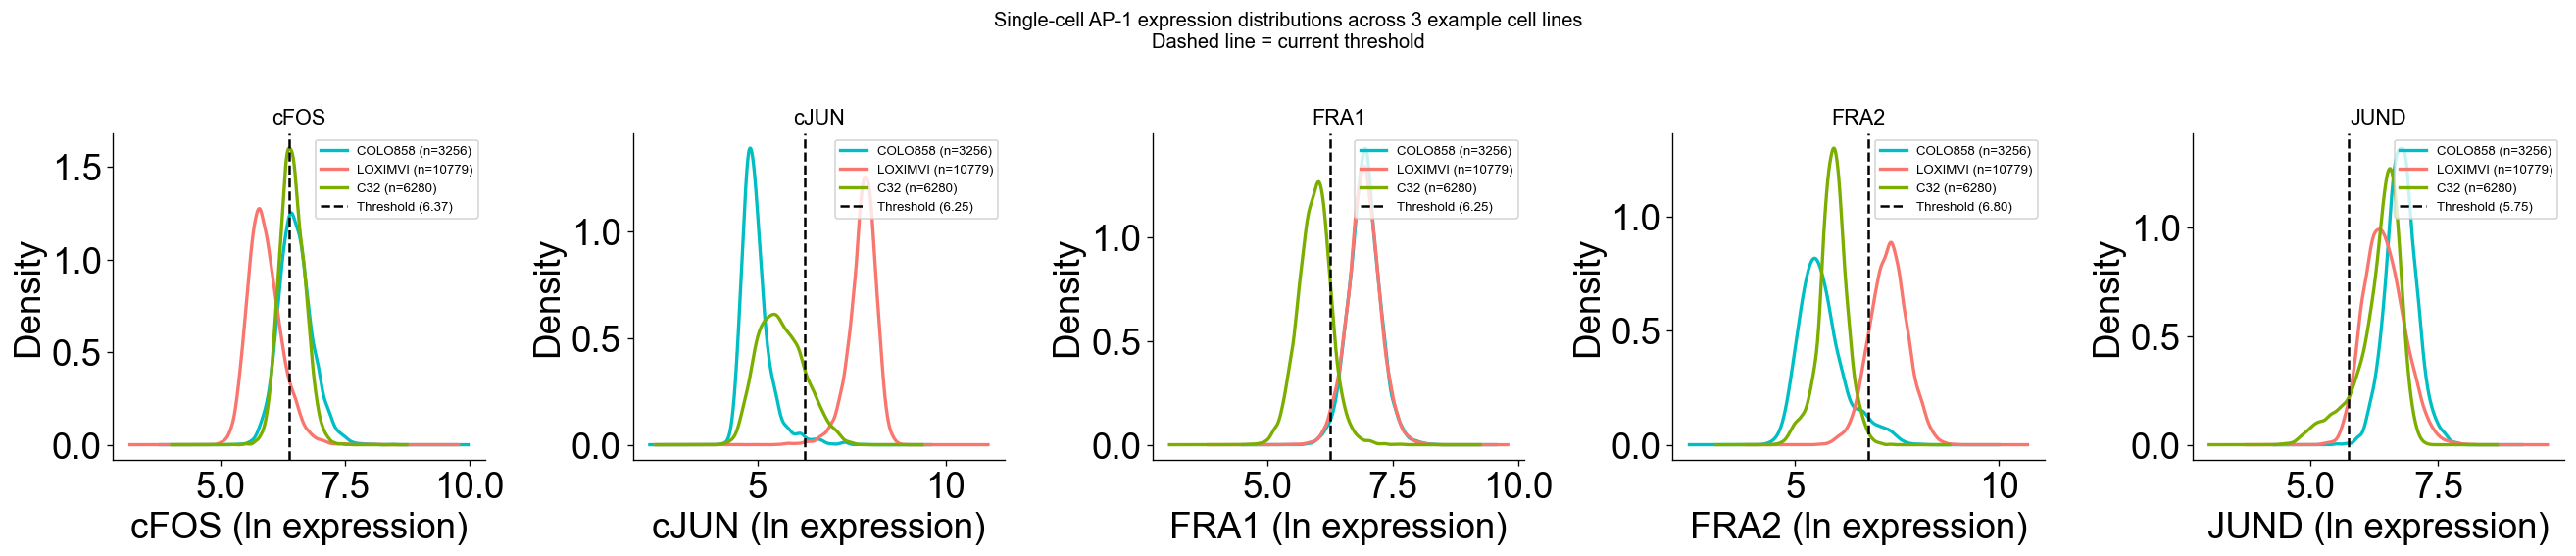

In [8]:
"""
Per-cell-line density distributions for 5 AP-1 proteins.
Plots single-cell distributions for COLO858, LOXIMVI, and C32 with
current thresholds overlaid as dashed lines.
"""

# Choose cell lines and assign colors
example_cell_lines = ['COLO858', 'LOXIMVI', 'C32']
cell_line_colors = {
    'COLO858': '#00BFC4',
    'LOXIMVI': '#F8766D',
    'C32':     '#7CAE00',
}

# Make sure rep1 was dropped — use the same df used everywhere else (ap1_df)
plot_df = ap1_df[ap1_df[CELL_LINE_COL].isin(example_cell_lines)].copy()
print("Cells per cell line in plot:")
print(plot_df[CELL_LINE_COL].value_counts())

fig, axes = plt.subplots(1, 5, figsize=(22, 4.5), sharey=False)

for ax, protein in zip(axes, PROTEINS):
    for cl in example_cell_lines:
        vals = plot_df.loc[plot_df[CELL_LINE_COL] == cl, protein].values
        # KDE via pandas (no seaborn dependency)
        pd.Series(vals).plot(
            kind='kde',
            ax=ax,
            color=cell_line_colors[cl],
            linewidth=2,
            label=f'{cl} (n={len(vals)})',
        )
    # Current threshold as vertical dashed line
    ax.axvline(
        CURRENT_THRESHOLDS[protein],
        color='black',
        linestyle='--',
        linewidth=1.5,
        label=f'Threshold ({CURRENT_THRESHOLDS[protein]:.2f})',
    )
    ax.set_title(protein, fontsize=13)
    ax.set_xlabel(f'{protein} (ln expression)')
    ax.set_ylabel('Density')
    ax.legend(fontsize=8, loc='upper right')

plt.suptitle(
    'Single-cell AP-1 expression distributions across 3 example cell lines\n'
    'Dashed line = current threshold',
    fontsize=12, y=1.04,
)
plt.tight_layout()
# plt.savefig('per_cell_line_distributions_examples.pdf',
#             dpi=200, bbox_inches='tight')
plt.show()

In [9]:
N_PER_CELL_LINE = 1000
SEED = 0
 
rng = np.random.default_rng(SEED)
sampled_dfs = []
sampling_report_rows = []
 
for cl, cl_df in ap1_df.groupby(CELL_LINE_COL):
    n_available = len(cl_df)
    rep_counts = cl_df[REPLICATE_COL].value_counts().to_dict()
 
    if n_available <= N_PER_CELL_LINE:
        # Take all
        sampled = cl_df.copy()
        method = 'all (under target)'
    else:
        # Draw proportionally across replicates
        # Compute per-replicate sample size proportional to replicate size
        rep_sizes = cl_df.groupby(REPLICATE_COL).size()
        proportions = rep_sizes / rep_sizes.sum()
        per_rep_target = (proportions * N_PER_CELL_LINE).round().astype(int)
 
        # Adjust for rounding so totals exactly hit N_PER_CELL_LINE
        diff = N_PER_CELL_LINE - per_rep_target.sum()
        if diff != 0:
            # Adjust the largest replicate's target by the difference
            largest_rep = rep_sizes.idxmax()
            per_rep_target[largest_rep] += diff
 
        parts = []
        for rep_id, n_take in per_rep_target.items():
            rep_df = cl_df[cl_df[REPLICATE_COL] == rep_id]
            n_take = min(n_take, len(rep_df))  # safety
            parts.append(rep_df.sample(n=n_take, random_state=rng.integers(0, 1e9)))
        sampled = pd.concat(parts, ignore_index=True)
        method = 'subsampled proportionally'
 
    sampled_dfs.append(sampled)
    sampling_report_rows.append({
        'cell_line': cl,
        'n_available': n_available,
        'n_sampled': len(sampled),
        'method': method,
        'rep_breakdown': dict(sampled[REPLICATE_COL].value_counts()),
    })
 
ap1_df_balanced = pd.concat(sampled_dfs, ignore_index=True)
sampling_report = pd.DataFrame(sampling_report_rows)
print(f"Total balanced cells: {len(ap1_df_balanced):,}")
print(f"Original total: {len(ap1_df):,}")
print(f"\nPer-cell-line sampling summary:")
print(sampling_report[['cell_line', 'n_available', 'n_sampled',
                       'method']].to_string(index=False))
print(f"\nCell lines under target (kept all): "
      f"{(sampling_report['n_sampled'] < N_PER_CELL_LINE).sum()}")


Total balanced cells: 18,765
Original total: 115,133

Per-cell-line sampling summary:
             cell_line  n_available  n_sampled                    method
                 A101D         4763       1000 subsampled proportionally
                 A2058         5066       1000 subsampled proportionally
                  A375        12646       1000 subsampled proportionally
A375 _x001A_NRAS(Q61K)         6807       1000 subsampled proportionally
                   C32         6280       1000 subsampled proportionally
               COLO858         3256       1000 subsampled proportionally
                HS294T         3421       1000 subsampled proportionally
                 IGR39         5645       1000 subsampled proportionally
               LOXIMVI        10779       1000 subsampled proportionally
                MMACSF         5736       1000 subsampled proportionally
                RVH421          765        765        all (under target)
               SKMEL19         6578   

In [10]:
from sklearn.mixture import GaussianMixture
 
def fit_pooled_gmm(values, random_state=0):
    """Fit a 2-component GMM to a 1D array of values."""
    X = values.reshape(-1, 1)
    gmm = GaussianMixture(n_components=2, random_state=random_state,
                          n_init=5, covariance_type='full')
    gmm.fit(X)
    # Sort components by mean so component 0 is always "low"
    order = np.argsort(gmm.means_.flatten())
    means = gmm.means_.flatten()[order]
    stds = np.sqrt(gmm.covariances_.flatten()[order])
    weights = gmm.weights_[order]
    return means, stds, weights
 
 
def gmm_posteriors(x, means, stds, weights):
    """Posterior P(component | x) for the two components."""
    from scipy.stats import norm
    # Likelihood-weighted by component prior
    p_low = weights[0] * norm.pdf(x, means[0], stds[0])
    p_high = weights[1] * norm.pdf(x, means[1], stds[1])
    total = p_low + p_high
    return p_low / total, p_high / total
 
 
def find_crossover(means, stds, weights, x_grid=None):
    """Find x where P(low|x) = P(high|x) = 0.5 (between the two component means)."""
    if x_grid is None:
        x_grid = np.linspace(means[0] - 3*stds[0], means[1] + 3*stds[1], 5000)
    p_low, p_high = gmm_posteriors(x_grid, means, stds, weights)
    # Restrict search to between the component means
    between = (x_grid >= means[0]) & (x_grid <= means[1])
    if between.sum() == 0:
        return None
    diff = np.abs(p_high[between] - 0.5)
    crossover_idx = np.argmin(diff)
    return x_grid[between][crossover_idx]
 
 
def find_posterior_range(means, stds, weights, low_q=0.1, high_q=0.9):
    """
    Find the range where the high-component posterior moves from low_q to high_q.
    This is the 'mixed zone' where classification is uncertain.
    """
    x_grid = np.linspace(means[0] - 3*stds[0], means[1] + 3*stds[1], 5000)
    _, p_high = gmm_posteriors(x_grid, means, stds, weights)
    range_lo = x_grid[np.argmin(np.abs(p_high - low_q))]
    range_hi = x_grid[np.argmin(np.abs(p_high - high_q))]
    return range_lo, range_hi
 


In [11]:
balanced_gmm_table_rows = []
balanced_gmm_fits = {}
 
for p in PROTEINS:
    values = ap1_df_balanced[p].values
    means, stds, weights = fit_pooled_gmm(values, random_state=SEED)
    crossover = find_crossover(means, stds, weights)
    range_lo, range_hi = find_posterior_range(means, stds, weights,
                                              low_q=0.1, high_q=0.9)
    current = CURRENT_THRESHOLDS[p]
    in_range = range_lo <= current <= range_hi
 
    balanced_gmm_fits[p] = dict(means=means, stds=stds, weights=weights)
    balanced_gmm_table_rows.append({
        'protein': p,
        'current_threshold': current,
        'gmm_threshold_balanced': crossover,
        'gmm_range_lo_balanced': range_lo,
        'gmm_range_hi_balanced': range_hi,
        'gmm_range_width_balanced': range_hi - range_lo,
        'current_in_range_balanced': in_range,
        'low_component_mean': means[0],
        'high_component_mean': means[1],
        'low_component_weight': weights[0],
        'high_component_weight': weights[1],
    })
 
balanced_gmm_table = pd.DataFrame(balanced_gmm_table_rows)
print("\n=== Balanced GMM threshold derivation ===")
print(balanced_gmm_table[['protein', 'current_threshold',
                          'gmm_threshold_balanced',
                          'gmm_range_lo_balanced', 'gmm_range_hi_balanced',
                          'gmm_range_width_balanced',
                          'current_in_range_balanced']].to_string(index=False))
 
print("\n=== Balanced GMM component structure ===")
print(balanced_gmm_table[['protein', 'low_component_mean',
                          'high_component_mean',
                          'low_component_weight',
                          'high_component_weight']].to_string(index=False))



=== Balanced GMM threshold derivation ===
protein  current_threshold  gmm_threshold_balanced  gmm_range_lo_balanced  gmm_range_hi_balanced  gmm_range_width_balanced  current_in_range_balanced
   cFOS               6.37                6.385735               5.659025               6.933521                  1.274496                       True
   cJUN               6.25                6.144161               5.518367               6.607927                  1.089560                       True
   FRA1               6.25                6.317973               5.864814               6.800157                  0.935344                       True
   FRA2               6.80                6.522568               5.941478               6.980551                  1.039074                       True
   JUND               5.75                6.398140               5.981263               7.066869                  1.085606                      False

=== Balanced GMM component structure ===
protein  low_co

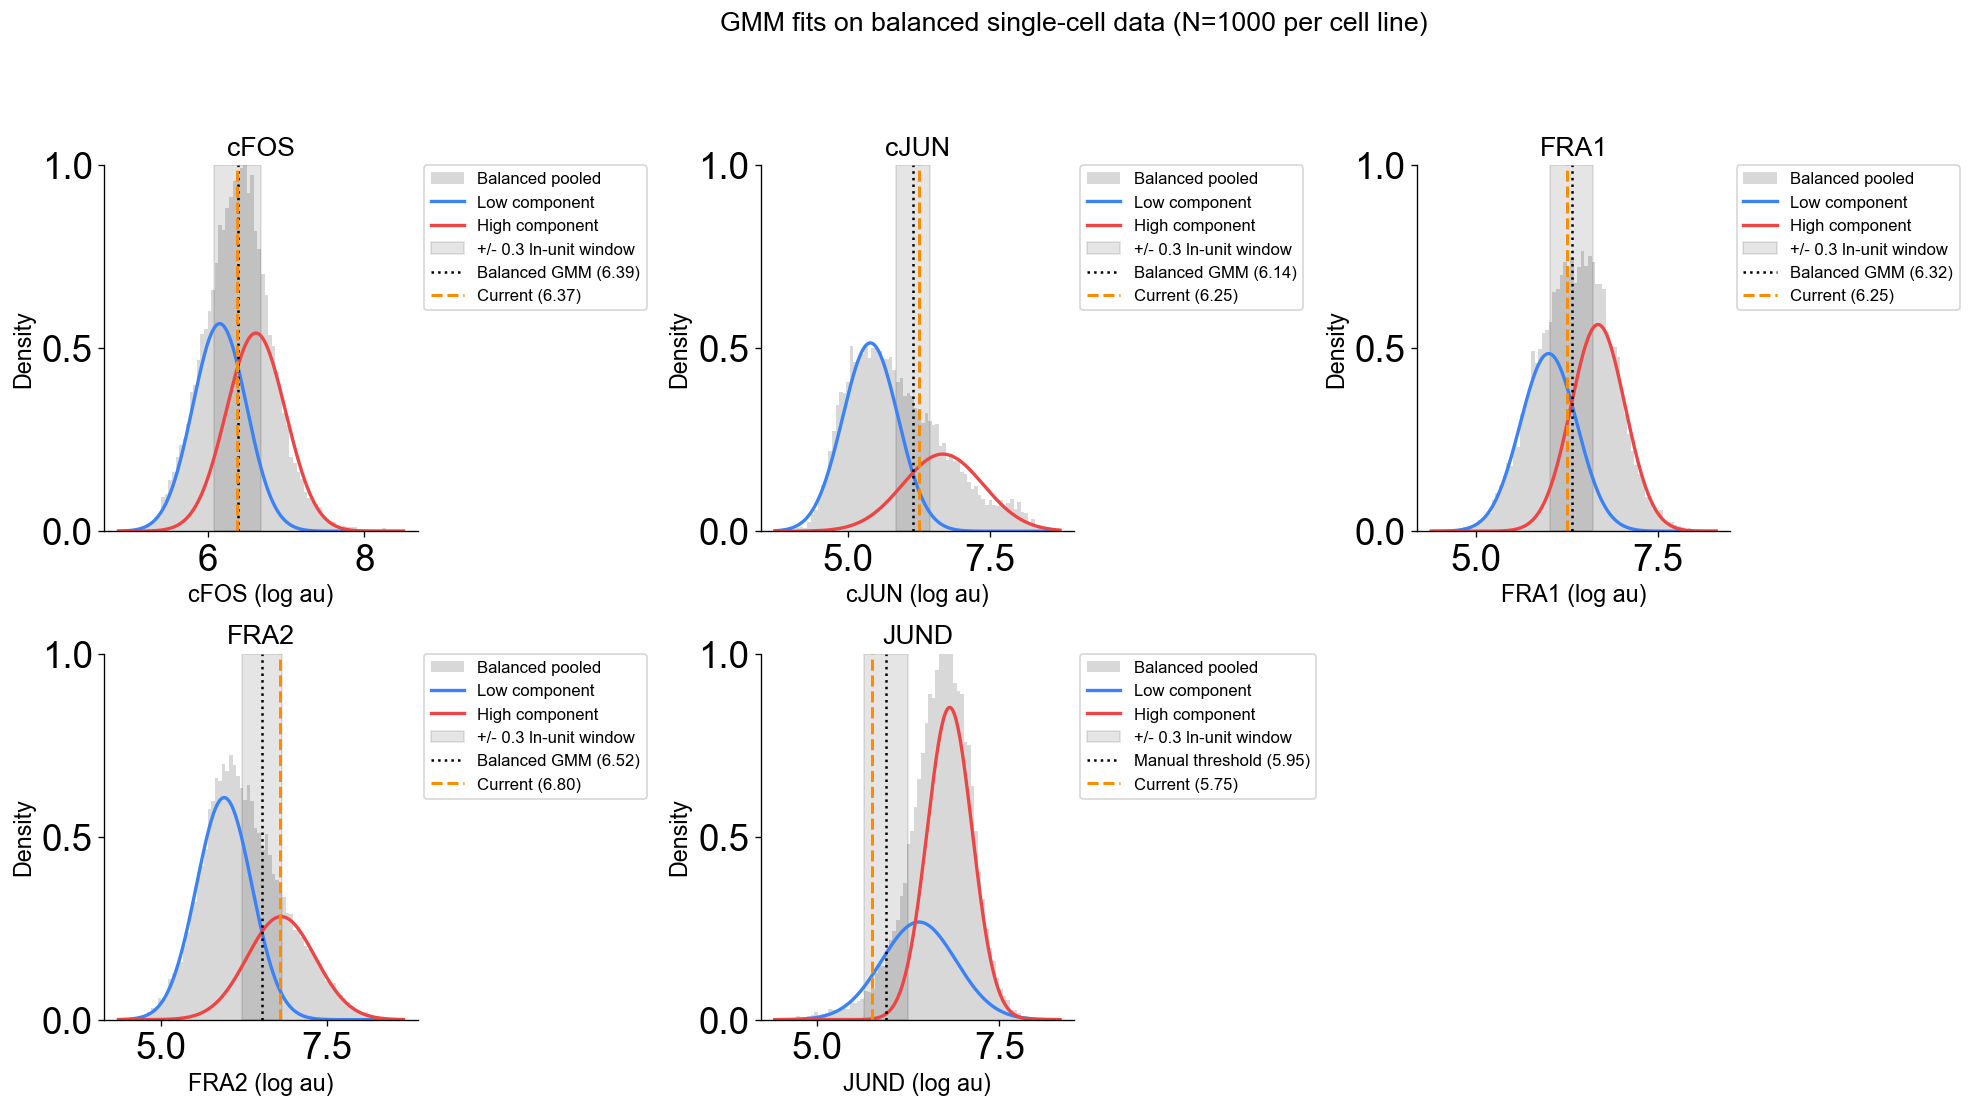

In [27]:
fig, axes = plt.subplots(2, 3, figsize=(18, 9), sharey=False)
axes = axes.flatten()

window_half_width = 0.3
manual_thresholds = {
    "JUND": 5.95,
}

for ax, (_, row) in zip(axes, balanced_gmm_table.iterrows()):
    p = row["protein"]
    values = ap1_df_balanced[p].values
    fit = balanced_gmm_fits[p]

    ax.hist(
        values,
        bins=80,
        density=True,
        alpha=0.3,
        color="gray",
        label="Balanced pooled",
    )

    x_grid = np.linspace(values.min(), values.max(), 1000)

    from scipy.stats import norm

    for i, comp_label in enumerate(["Low component", "High component"]):
        comp_pdf = (
            fit["weights"][i]
            * norm.pdf(x_grid, fit["means"][i], fit["stds"][i])
        )

        ax.plot(
            x_grid,
            comp_pdf,
            color=("#3b82f6" if i == 0 else "#ef4444"),
            linewidth=2,
            label=comp_label,
        )

    if p in manual_thresholds:
        plot_threshold = manual_thresholds[p]
        threshold_label = f"Manual threshold ({plot_threshold:.2f})"
    else:
        plot_threshold = row["gmm_threshold_balanced"]
        threshold_label = f"Balanced GMM ({plot_threshold:.2f})"

    ax.axvspan(
        plot_threshold - window_half_width,
        plot_threshold + window_half_width,
        alpha=0.10,
        color="black",
        label=f"+/- {window_half_width} ln-unit window",
    )

    ax.axvline(
        plot_threshold,
        color="black",
        linestyle=":",
        linewidth=1.5,
        label=threshold_label,
    )

    ax.axvline(
        row["current_threshold"],
        color="darkorange",
        linestyle="--",
        linewidth=1.8,
        label=f'Current ({row["current_threshold"]:.2f})',
    )

    ax.set_title(p, fontsize=16)
    ax.set_xlabel(f"{p} (log au)", fontsize=14)
    ax.set_ylabel("Density", fontsize=14)
    ax.set_ylim(0, 1)
    ax.set_yticks([0, 0.5, 1])

    ax.legend(
        fontsize=10,
        loc="upper left",
        bbox_to_anchor=(1.02, 1),
        borderaxespad=0,
    )

# Hide unused 6th panel since there are 5 proteins
for ax in axes[len(balanced_gmm_table):]:
    ax.axis("off")

plt.suptitle(
    f"GMM fits on balanced single-cell data (N={N_PER_CELL_LINE} per cell line)",
    fontsize=16,
    y=1.02,
)

plt.tight_layout(rect=[0, 0, 0.92, 0.96])

plt.savefig(
    "balanced_gmm_derivation_all_celllines.pdf",
    dpi=200,
    bbox_inches="tight",
)

plt.show()

#### Subset cells to three highest and lowest for each ap-1 protein

In [14]:
from scipy.stats import norm

# ============================================
# Protein-specific top/bottom 3 cell-line GMMs
# ============================================

N_ANCHOR_LINES = 3

# Rank cell lines by replicate-aware expression summary.
# Median per replicate, then median across replicates per cell line.
per_rep_medians = (
    ap1_df.groupby([CELL_LINE_COL, REPLICATE_COL])[PROTEINS]
          .median()
)

cell_line_summary_for_subset = (
    per_rep_medians.groupby(CELL_LINE_COL)
                   .median()
)

subset_gmm_table_rows = []
subset_gmm_fits = {}

for p in PROTEINS:
    ranked = cell_line_summary_for_subset[p].sort_values()

    low_anchor_cells = ranked.head(N_ANCHOR_LINES).index.tolist()
    high_anchor_cells = ranked.tail(N_ANCHOR_LINES).index.tolist()
    selected_cells = low_anchor_cells + high_anchor_cells

    # Use balanced data so each selected cell line contributes similarly.
    subset_df = ap1_df_balanced[
        ap1_df_balanced[CELL_LINE_COL].isin(selected_cells)
    ].copy()

    values = subset_df[p].dropna().values

    means, stds, weights = fit_pooled_gmm(values, random_state=SEED)
    crossover = find_crossover(means, stds, weights)
    range_lo, range_hi = find_posterior_range(
        means, stds, weights,
        low_q=0.1,
        high_q=0.9
    )

    current = CURRENT_THRESHOLDS[p]

    subset_gmm_fits[p] = {
        "means": means,
        "stds": stds,
        "weights": weights,
        "low_anchor_cells": low_anchor_cells,
        "high_anchor_cells": high_anchor_cells,
        "selected_cells": selected_cells,
        "values": values,
    }

    subset_gmm_table_rows.append({
        "protein": p,
        "current_threshold": current,
        "subset_gmm_threshold": crossover,
        "abs_delta_from_current": abs(crossover - current),
        "subset_gmm_range_lo": range_lo,
        "subset_gmm_range_hi": range_hi,
        "subset_gmm_range_width": range_hi - range_lo,
        "current_in_subset_range": range_lo <= current <= range_hi,
        "low_anchor_cells": low_anchor_cells,
        "high_anchor_cells": high_anchor_cells,
        "n_cells_used": len(subset_df),
        "low_component_mean": means[0],
        "high_component_mean": means[1],
        "low_component_weight": weights[0],
        "high_component_weight": weights[1],
    })

subset_gmm_table = pd.DataFrame(subset_gmm_table_rows)

print("\n=== Protein-specific top/bottom 3 GMM threshold derivation ===")
print(
    subset_gmm_table[
        [
            "protein",
            "current_threshold",
            "subset_gmm_threshold",
            "abs_delta_from_current",
            "subset_gmm_range_lo",
            "subset_gmm_range_hi",
            "subset_gmm_range_width",
            "current_in_subset_range",
            "n_cells_used",
        ]
    ].to_string(index=False)
)

print("\n=== Anchor cell lines used for each protein ===")
for _, row in subset_gmm_table.iterrows():
    print(f"\n{row['protein']}")
    print(f"  Low anchors:  {row['low_anchor_cells']}")
    print(f"  High anchors: {row['high_anchor_cells']}")


=== Protein-specific top/bottom 3 GMM threshold derivation ===
protein  current_threshold  subset_gmm_threshold  abs_delta_from_current  subset_gmm_range_lo  subset_gmm_range_hi  subset_gmm_range_width  current_in_subset_range  n_cells_used
   cFOS               6.37              6.289042                0.080958             6.034314             6.501801                0.467487                     True          6000
   cJUN               6.25              6.018396                0.231604             5.681334             6.302956                0.621621                     True          6000
   FRA1               6.25              6.385577                0.135577             6.126455             6.654910                0.528455                     True          5765
   FRA2               6.80              6.415392                0.384608             6.147035             6.675093                0.528059                    False          6000
   JUND               5.75              6.6594

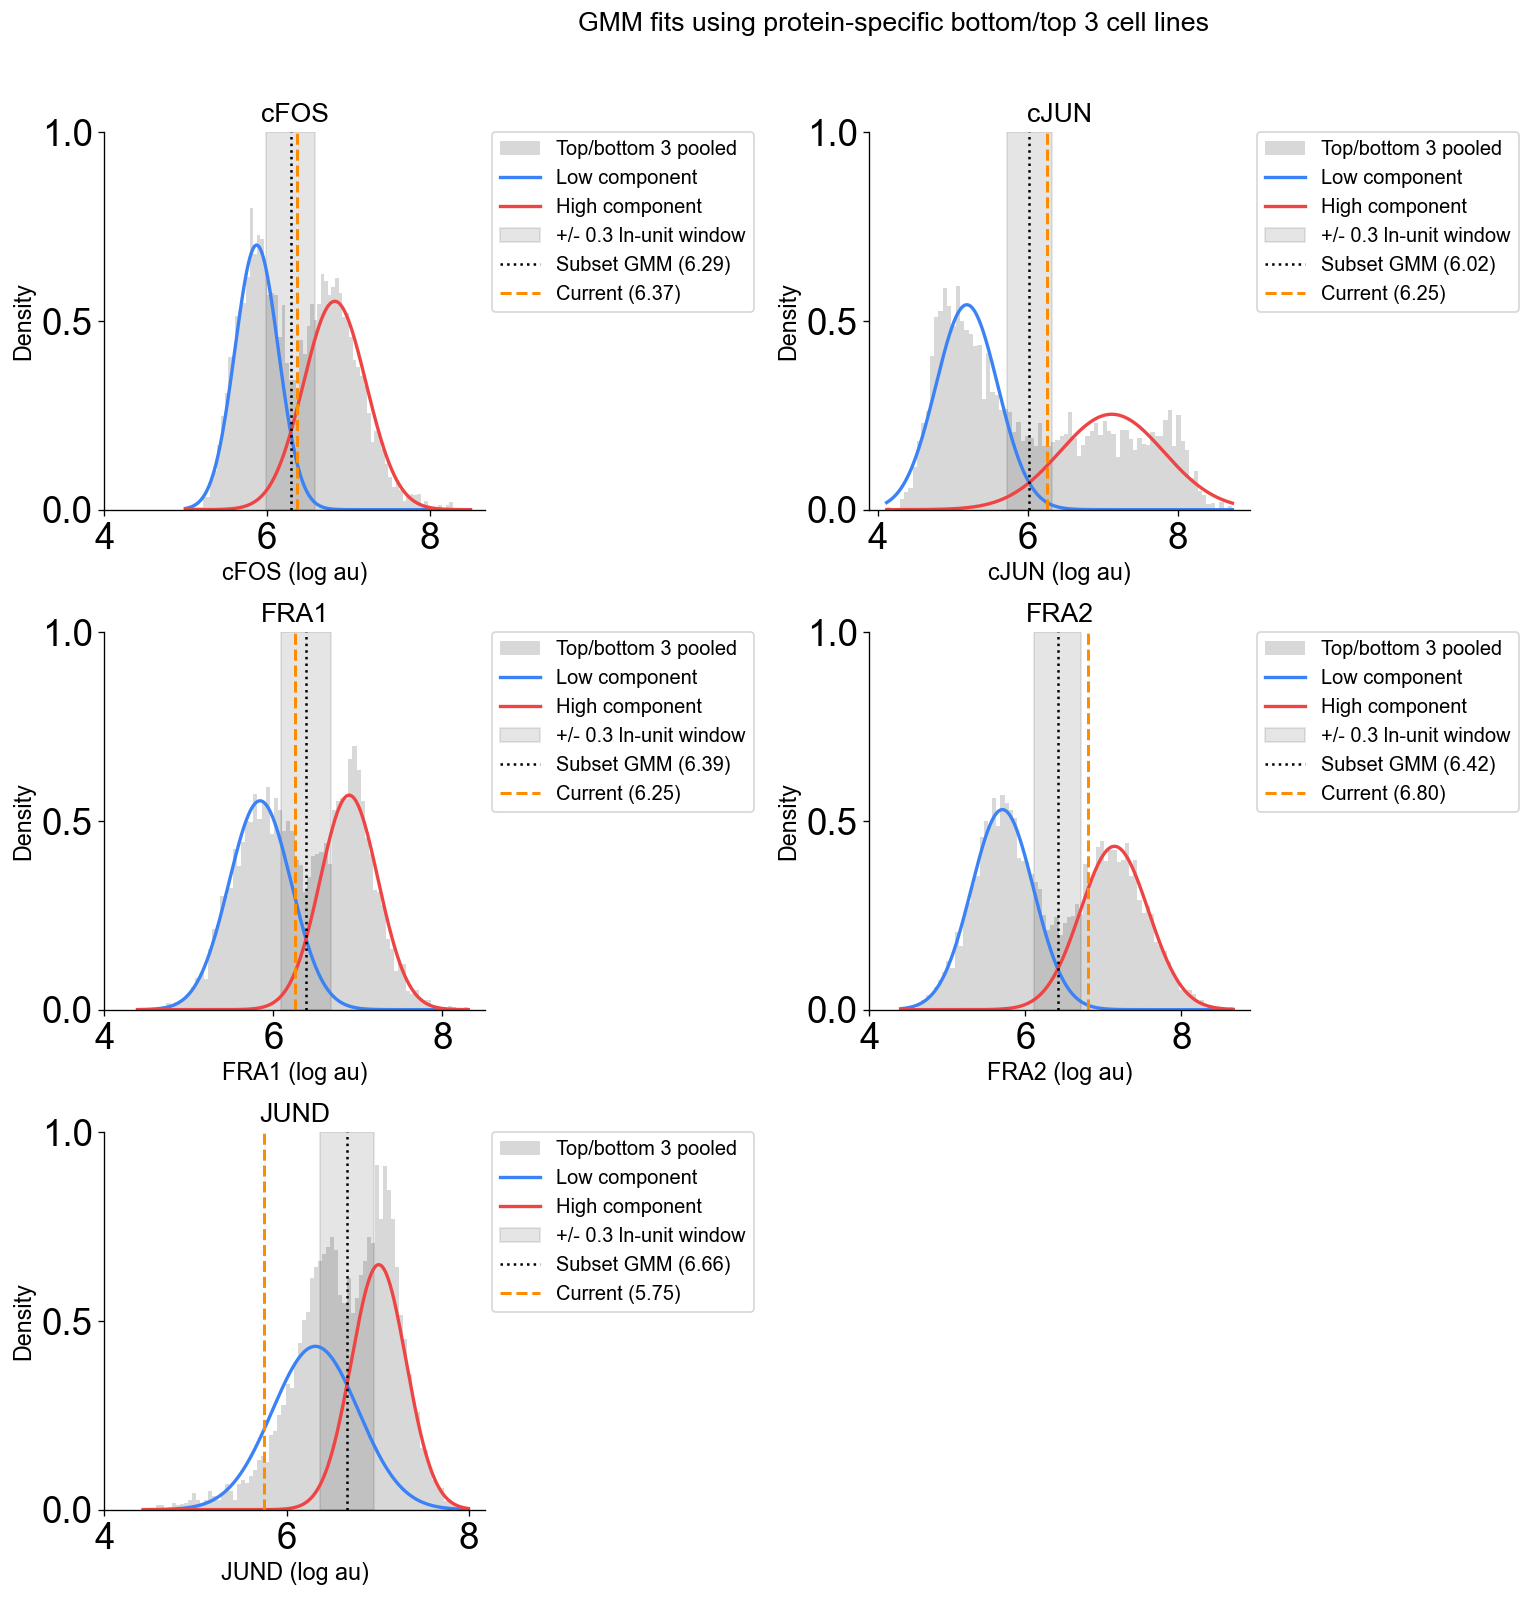

In [15]:
fig, axes = plt.subplots(3, 2, figsize=(15, 13), sharey=False)
axes = axes.flatten()

for ax, (_, row) in zip(axes, subset_gmm_table.iterrows()):
    p = row["protein"]
    fit = subset_gmm_fits[p]
    values = fit["values"]

    ax.hist(
        values,
        bins=80,
        density=True,
        alpha=0.3,
        color="gray",
        label="Top/bottom 3 pooled"
    )

    x_grid = np.linspace(values.min(), values.max(), 1000)

    for i, comp_label in enumerate(["Low component", "High component"]):
        comp_pdf = (
            fit["weights"][i]
            * norm.pdf(x_grid, fit["means"][i], fit["stds"][i])
        )

        ax.plot(
            x_grid,
            comp_pdf,
            color=("#3b82f6" if i == 0 else "#ef4444"),
            linewidth=2,
            label=comp_label
        )
    window_half_width = 0.3
    gmm_threshold = row["subset_gmm_threshold"]

    ax.axvspan(
        gmm_threshold - window_half_width,
        gmm_threshold + window_half_width,
        color="black",
        alpha=0.10,
        label=f"+/- {window_half_width} ln-unit window",
    )
    ax.axvline(
        row["subset_gmm_threshold"],
        color="black",
        linestyle=":",
        linewidth=1.5,
        label=f'Subset GMM ({row["subset_gmm_threshold"]:.2f})'
    )

    ax.axvline(
        row["current_threshold"],
        color="darkorange",
        linestyle="--",
        linewidth=1.8,
        label=f'Current ({row["current_threshold"]:.2f})'
    )

    ax.set_title(p, fontsize=16)
    ax.set_xlabel(f"{p} (log au)", fontsize=14)
    ax.set_ylabel("Density", fontsize=14)
    ax.set_ylim(0, 1)
    ax.set_yticks([0, 0.5, 1])
    ax.set_xticks([4,6,8])

    ax.legend(
        fontsize=12,
        loc="upper left",
        bbox_to_anchor=(1.02, 1),
        borderaxespad=0,
    )

# Hide unused 6th panel since there are 5 proteins
for ax in axes[len(subset_gmm_table):]:
    ax.axis("off")

plt.suptitle(
    f"GMM fits using protein-specific bottom/top {N_ANCHOR_LINES} cell lines",
    fontsize=16,
    y=1.02,
)

plt.tight_layout(rect=[0, 0, 0.86, 1])
plt.savefig("protein_specific_subset_gmm_derivation_with_current_thresholds.pdf", dpi=200, bbox_inches="tight")
plt.show()

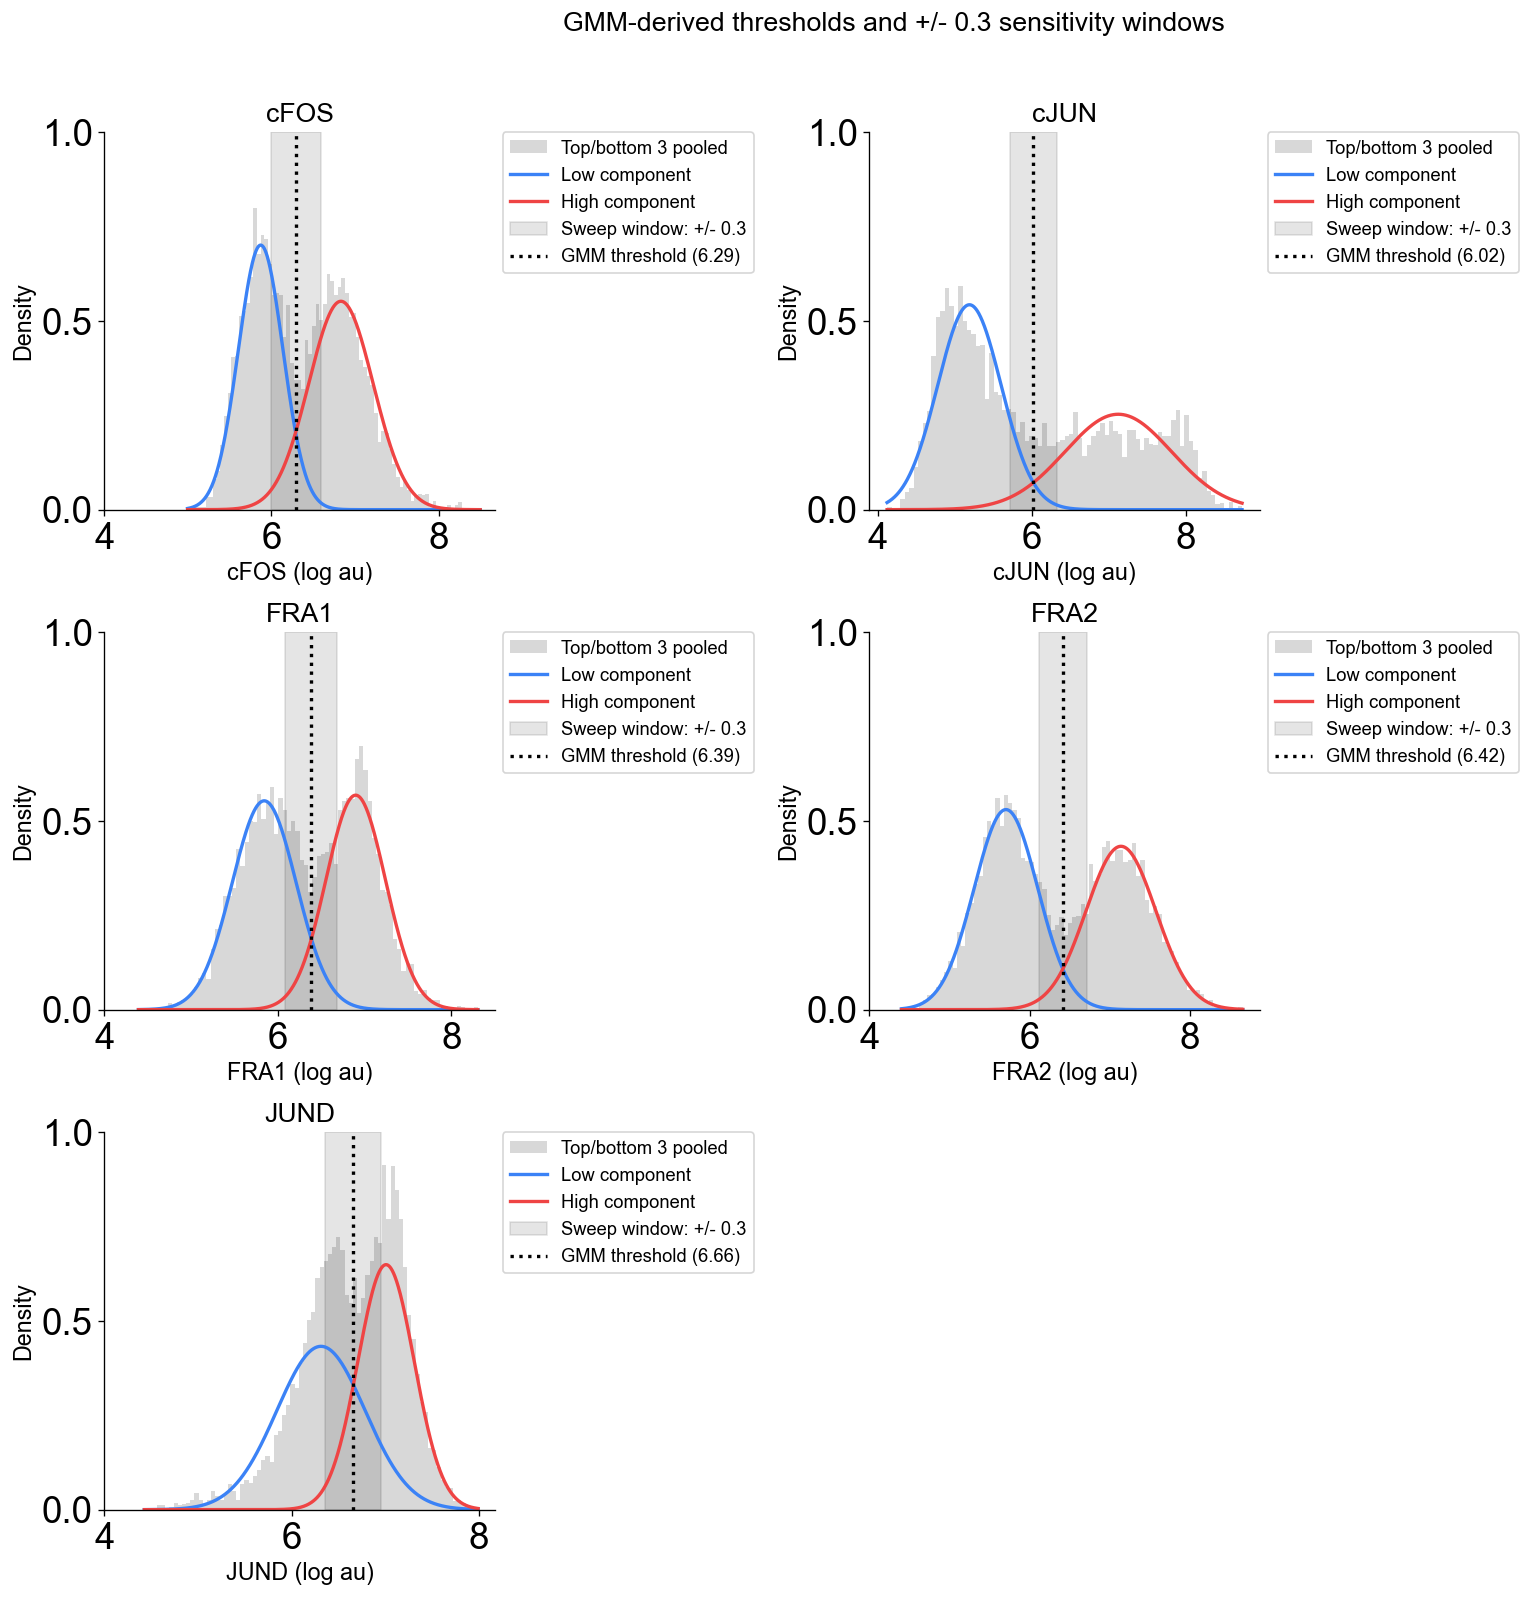

In [32]:
# modified code
WINDOW_HALF_WIDTH = 0.3

fig, axes = plt.subplots(3, 2, figsize=(15, 13), sharey=False)
axes = axes.flatten()

for ax, (_, row) in zip(axes, subset_gmm_table.iterrows()):
    p = row["protein"]
    fit = subset_gmm_fits[p]
    values = fit["values"]

    gmm_threshold = row["subset_gmm_threshold"]
    window_lo = gmm_threshold - WINDOW_HALF_WIDTH
    window_hi = gmm_threshold + WINDOW_HALF_WIDTH

    ax.hist(
        values,
        bins=80,
        density=True,
        alpha=0.3,
        color="gray",
        label="Top/bottom 3 pooled",
    )

    x_grid = np.linspace(values.min(), values.max(), 1000)

    for i, comp_label in enumerate(["Low component", "High component"]):
        comp_pdf = (
            fit["weights"][i]
            * norm.pdf(x_grid, fit["means"][i], fit["stds"][i])
        )

        ax.plot(
            x_grid,
            comp_pdf,
            color=("#3b82f6" if i == 0 else "#ef4444"),
            linewidth=2,
            label=comp_label,
        )

    ax.axvspan(
        window_lo,
        window_hi,
        color="black",
        alpha=0.10,
        label=f"Sweep window: +/- {WINDOW_HALF_WIDTH}",
    )

    ax.axvline(
        gmm_threshold,
        color="black",
        linestyle=":",
        linewidth=2,
        label=f"GMM threshold ({gmm_threshold:.2f})",
    )

    ax.set_title(p, fontsize=16)
    ax.set_xlabel(f"{p} (log au)", fontsize=14)
    ax.set_ylabel("Density", fontsize=14)
    ax.set_ylim(0, 1)
    ax.set_yticks([0, 0.5, 1])
    ax.set_xticks([4, 6, 8])

    ax.legend(
        fontsize=11,
        loc="upper left",
        bbox_to_anchor=(1.02, 1),
        borderaxespad=0,
    )

# Hide unused 6th panel since there are 5 proteins
for ax in axes[len(subset_gmm_table):]:
    ax.axis("off")

plt.suptitle(
    f"GMM-derived thresholds and +/- {WINDOW_HALF_WIDTH} sensitivity windows",
    fontsize=16,
    y=1.02,
)

plt.tight_layout(rect=[0, 0, 0.86, 1])

plt.savefig(
    "protein_specific_anchor_gmm_thresholds_with_sweep_windows.pdf",
    dpi=200,
    bbox_inches="tight",
)

plt.show()

In [16]:
subset_gmm_table["signed_difference"] = (
    subset_gmm_table["subset_gmm_threshold"]
    - subset_gmm_table["current_threshold"]
)

subset_gmm_table["absolute_difference"] = (
    subset_gmm_table["signed_difference"].abs()
)

print("\n=== Difference between current and subset GMM thresholds ===")
print(
    subset_gmm_table[
        [
            "protein",
            "current_threshold",
            "subset_gmm_threshold",
            "signed_difference",
            "absolute_difference",
        ]
    ].to_string(index=False)
)


=== Difference between current and subset GMM thresholds ===
protein  current_threshold  subset_gmm_threshold  signed_difference  absolute_difference
   cFOS               6.37              6.289042          -0.080958             0.080958
   cJUN               6.25              6.018396          -0.231604             0.231604
   FRA1               6.25              6.385577           0.135577             0.135577
   FRA2               6.80              6.415392          -0.384608             0.384608
   JUND               5.75              6.659498           0.909498             0.909498


In [20]:
## Options:
#   "current"      = current/original thresholds
#   "subset_gmm"   = protein-specific top/bottom anchor-cell GMM
#   "balanced_gmm" = GMM fit on balanced pooled single-cell data
SWEEP_THRESHOLD_SOURCE = "current"

WINDOW_HALF_WIDTH = 0.3
N_GRID_PER_PROTEIN = 3

if SWEEP_THRESHOLD_SOURCE == "current":
    sweep_threshold_table = pd.DataFrame({
        "protein": PROTEINS,
        "sweep_threshold": [CURRENT_THRESHOLDS[p] for p in PROTEINS],
    }).set_index("protein")
    SWEEP_THRESHOLD_COLUMN = "sweep_threshold"

elif SWEEP_THRESHOLD_SOURCE == "subset_gmm":
    sweep_threshold_table = (
        subset_gmm_table
        .set_index("protein")
        .reindex(PROTEINS)
    )
    SWEEP_THRESHOLD_COLUMN = "subset_gmm_threshold"

elif SWEEP_THRESHOLD_SOURCE == "balanced_gmm":
    sweep_threshold_table = (
        balanced_gmm_table
        .set_index("protein")
        .reindex(PROTEINS)
    )
    SWEEP_THRESHOLD_COLUMN = "gmm_threshold_balanced"

else:
    raise ValueError(
        "SWEEP_THRESHOLD_SOURCE must be 'current', 'subset_gmm', or 'balanced_gmm'"
    )

if sweep_threshold_table[SWEEP_THRESHOLD_COLUMN].isna().any():
    missing = sweep_threshold_table.index[
        sweep_threshold_table[SWEEP_THRESHOLD_COLUMN].isna()
    ].tolist()
    raise ValueError(f"Missing thresholds for: {missing}")

REFERENCE_THRESHOLDS = sweep_threshold_table[SWEEP_THRESHOLD_COLUMN].to_dict()
# Optional manual override for JUND.
# Apply only when using GMM-derived thresholds, not when using current thresholds.
if SWEEP_THRESHOLD_SOURCE in {"subset_gmm", "balanced_gmm"}:
    REFERENCE_THRESHOLDS["JUND"] = 5.95

print(
    f"Sensitivity window: {SWEEP_THRESHOLD_SOURCE} threshold "
    f"+/- {WINDOW_HALF_WIDTH} ln-units"
)
print(f"Grid resolution: {N_GRID_PER_PROTEIN} values per protein")


# ============================================
# Build threshold range table
# ============================================

narrow_rows = []
for p in PROTEINS:
    reference = REFERENCE_THRESHOLDS[p]
    current = CURRENT_THRESHOLDS[p]

    range_lo = reference - WINDOW_HALF_WIDTH
    range_hi = reference + WINDOW_HALF_WIDTH

    narrow_rows.append({
        "protein": p,
        "current_threshold": current,
        "reference_threshold": reference,
        "threshold_source": SWEEP_THRESHOLD_SOURCE,
        "range_lo": range_lo,
        "range_hi": range_hi,
        "range_width": range_hi - range_lo,
    })

narrow_table = pd.DataFrame(narrow_rows)

print("\n=== Sensitivity ranges ===")
print(narrow_table.to_string(index=False))


# ============================================
# Reference recurrent states at chosen threshold source
# ============================================

print(f"\n=== Reference run using {SWEEP_THRESHOLD_SOURCE} thresholds ===")

ref_state_df = assign_states_vectorized(ap1_df, REFERENCE_THRESHOLDS)
reference_recurrent, ref_avg_freq = identify_recurrent_states(ref_state_df)

print(f"Number of recurrent states: {len(reference_recurrent)}")
for s in sorted(reference_recurrent):
    s_str = " | ".join(f"{p}={v}" for p, v in zip(PROTEINS, s))
    print(f"  {s_str}")


# ============================================
# Build sensitivity grid
# ============================================

grid_values = {}
for _, row in narrow_table.iterrows():
    p = row["protein"]

    base_grid = np.linspace(
        row["range_lo"],
        row["range_hi"],
        N_GRID_PER_PROTEIN,
    )

    # Ensure the exact reference threshold is included in the grid.
    vals = np.sort(np.unique(np.append(base_grid, row["reference_threshold"])))
    grid_values[p] = vals

print("\nGrid values per protein:")
for p, vals in grid_values.items():
    print(f"  {p} ({len(vals)} vals): {[f'{v:.3f}' for v in vals]}")

combos = list(product(*[grid_values[p] for p in PROTEINS]))

print(f"\nTotal threshold combinations: {len(combos):,}")

Sensitivity window: current threshold +/- 0.3 ln-units
Grid resolution: 3 values per protein

=== Sensitivity ranges ===
protein  current_threshold  reference_threshold threshold_source  range_lo  range_hi  range_width
   cFOS               6.37                 6.37          current      6.07      6.67          0.6
   cJUN               6.25                 6.25          current      5.95      6.55          0.6
   FRA1               6.25                 6.25          current      5.95      6.55          0.6
   FRA2               6.80                 6.80          current      6.50      7.10          0.6
   JUND               5.75                 5.75          current      5.45      6.05          0.6

=== Reference run using current thresholds ===
Number of recurrent states: 6
  cFOS=high | cJUN=low | FRA1=high | FRA2=low | JUND=high
  cFOS=high | cJUN=low | FRA1=low | FRA2=low | JUND=high
  cFOS=low | cJUN=high | FRA1=high | FRA2=high | JUND=high
  cFOS=low | cJUN=high | FRA1=high | FR

In [ ]:
# print(f"\n=== Reference run using {SWEEP_THRESHOLD_SOURCE} thresholds ===")
# ref_state_df = assign_states_vectorized(ap1_df, REFERENCE_THRESHOLDS)
# reference_recurrent, ref_avg_freq = identify_recurrent_states(ref_state_df)
# print(f"Number of recurrent states: {len(reference_recurrent)}")
# for s in sorted(reference_recurrent):
#     s_str = ' | '.join(f"{p}={v}" for p, v in zip(PROTEINS, s))
#     print(f"  {s_str}")
 
 
# # %% Cell 4: Build sensitivity grid =========================================
# grid_values = {}
# for _, row in narrow_table.iterrows():
#     p = row['protein']
#     base_grid = np.linspace(row['range_lo'], row['range_hi'],
#                             N_GRID_PER_PROTEIN)
#     vals = np.sort(np.unique(np.append(base_grid, row['reference_threshold'])))
#     grid_values[p] = vals
 
# print(f"\nGrid values per protein:")
# for p, vals in grid_values.items():
#     print(f"  {p} ({len(vals)} vals): {[f'{v:.3f}' for v in vals]}")
 
# combos = list(product(*[grid_values[p] for p in PROTEINS]))
# print(f"\nTotal threshold combinations: {len(combos):,}")



=== Reference run using subset_gmm thresholds ===
Number of recurrent states: 6
  cFOS=high | cJUN=low | FRA1=high | FRA2=low | JUND=high
  cFOS=high | cJUN=low | FRA1=low | FRA2=high | JUND=high
  cFOS=high | cJUN=low | FRA1=low | FRA2=low | JUND=high
  cFOS=low | cJUN=high | FRA1=high | FRA2=high | JUND=high
  cFOS=low | cJUN=low | FRA1=high | FRA2=low | JUND=high
  cFOS=low | cJUN=low | FRA1=low | FRA2=low | JUND=high

Grid values per protein:
  cFOS (5 vals): ['5.789', '6.039', '6.289', '6.539', '6.789']
  cJUN (5 vals): ['5.518', '5.768', '6.018', '6.268', '6.518']
  FRA1 (5 vals): ['5.886', '6.136', '6.386', '6.636', '6.886']
  FRA2 (5 vals): ['5.915', '6.165', '6.415', '6.665', '6.915']
  JUND (5 vals): ['5.450', '5.700', '5.950', '6.200', '6.450']

Total threshold combinations: 3,125


In [21]:
sweep_results = []
all_recurrent_sets = []
for combo in tqdm(combos, desc="Sweep"):
    thr = dict(zip(PROTEINS, combo))
    state_df = assign_states_vectorized(ap1_df, thr)
    rec_set, _ = identify_recurrent_states(state_df)
    sweep_results.append({
        **{p: combo[i] for i, p in enumerate(PROTEINS)},
        'n_recurrent': len(rec_set),
        'jaccard_to_reference': jaccard(rec_set, reference_recurrent),
        'matches_reference': rec_set == reference_recurrent,
        'recovers_all_reference': reference_recurrent.issubset(rec_set),
    })
    all_recurrent_sets.append(rec_set)
 
sweep_df = pd.DataFrame(sweep_results)
# sweep_df.to_csv(
#     f'{SWEEP_THRESHOLD_SOURCE}_sweep_results_w{WINDOW_HALF_WIDTH}.csv',
#     index=False,
# )


Sweep:   0%|          | 0/243 [00:00<?, ?it/s]

In [11]:
# %% Cell 6: Headline summary numbers ======================================
print("\n=== Headline numbers for reviewer response ===")
print(f"Total threshold combinations tested: {len(sweep_df):,}")
print(f"Combinations recovering all 6 reference states (possibly + extras): "
      f"{sweep_df['recovers_all_reference'].sum():,} "
      f"({100 * sweep_df['recovers_all_reference'].mean():.1f}%)")
print(f"Combinations matching reference exactly: "
      f"{sweep_df['matches_reference'].sum():,} "
      f"({100 * sweep_df['matches_reference'].mean():.1f}%)")
print(f"Mean Jaccard to reference: {sweep_df['jaccard_to_reference'].mean():.3f}")
print(f"Combinations with Jaccard >= 0.8: "
      f"{100 * (sweep_df['jaccard_to_reference'] >= 0.8).mean():.1f}%")
 



=== Headline numbers for reviewer response ===
Total threshold combinations tested: 243
Combinations recovering all 6 reference states (possibly + extras): 156 (64.2%)
Combinations matching reference exactly: 63 (25.9%)
Mean Jaccard to reference: 0.839
Combinations with Jaccard >= 0.8: 64.2%


In [22]:
from collections import Counter
state_counter = Counter()
for s in all_recurrent_sets:
    for state in s:
        state_counter[state] += 1
 
all_possible_states = list(product(['low', 'high'], repeat=len(PROTEINS)))
stability_rows = []
for state in all_possible_states:
    count = state_counter.get(state, 0)
    # Build a compact label: e.g., "F+ J- 1+ 2- D+"
    short = []
    for p, v in zip(PROTEINS, state):
        sym = '+' if v == 'high' else '-'
        short.append(f"{p[-1]}{sym}" if p.startswith('FRA') else f"{p[1]}{sym}")
    label = ' '.join(short)
    stability_rows.append({
        'state': state,
        'state_label': label,
        'recurrence_frequency': count / len(all_recurrent_sets),
        'in_reference': state in reference_recurrent,
    })
stability_df = (pd.DataFrame(stability_rows)
                  .sort_values('recurrence_frequency', ascending=False)
                  .reset_index(drop=True))
# stability_df.to_csv(
#     f'{SWEEP_THRESHOLD_SOURCE}_per_state_stability_w{WINDOW_HALF_WIDTH}.csv',
#     index=False,
# )
 


Showing 18 states; hiding 14 that never appeared as recurrent.
Reference states are the top 6 most stable states: True


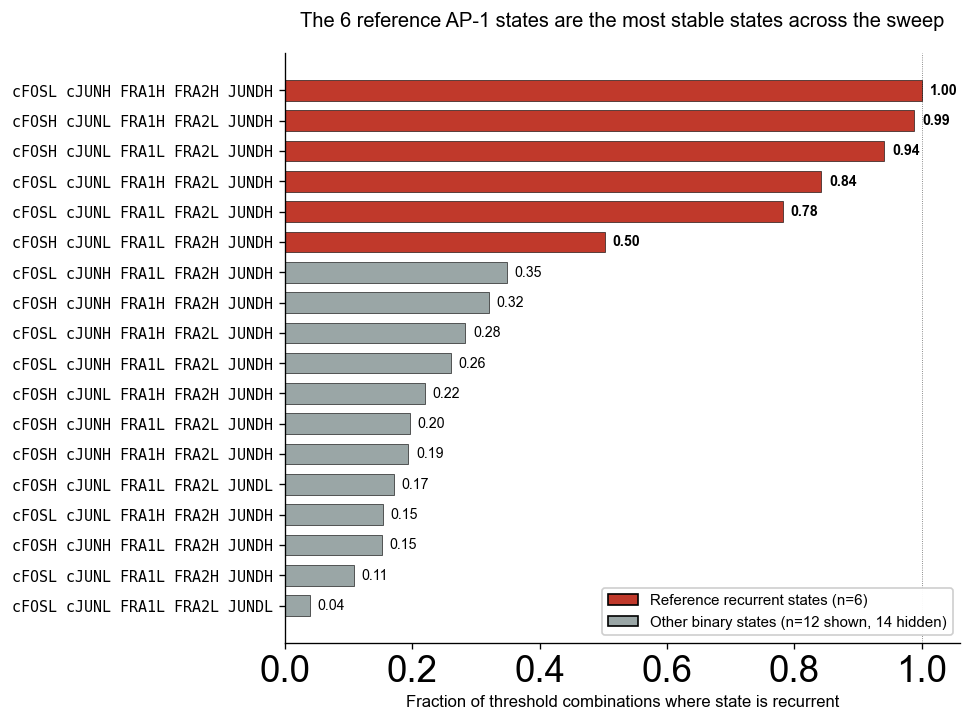

In [21]:
# %% Build clearer state labels =============================================
def make_clean_label(state):
    parts = []
    for p, v in zip(PROTEINS, state):
        sym = "H" if v == "high" else "L"
        parts.append(f"{p}{sym}")
    return " ".join(parts)


stability_df["clean_label"] = stability_df["state"].apply(make_clean_label)

visible_mask = (
    (stability_df["recurrence_frequency"] > 0)
    | stability_df["in_reference"]
)
visible_df = stability_df[visible_mask].reset_index(drop=True)

n_visible = len(visible_df)
n_ref = len(reference_recurrent)
n_hidden = (~visible_mask).sum()
n_other_visible = n_visible - n_ref

print(
    f"Showing {n_visible} states; hiding {n_hidden} "
    "that never appeared as recurrent."
)

top_states = set(visible_df.head(n_ref)["state"])
reference_states_are_top = top_states == reference_recurrent
print(
    f"Reference states are the top {n_ref} most stable states: "
    f"{reference_states_are_top}"
)


# %% Build the figure =======================================================
fig_height = max(5.5, 0.34 * n_visible)
fig, ax = plt.subplots(figsize=(8.2, fig_height))

y_pos = np.arange(n_visible)

reference_color = "#c0392b"
other_color = "#9aa6a6"

colors = [
    reference_color if is_ref else other_color
    for is_ref in visible_df["in_reference"]
]

ax.barh(
    y_pos,
    visible_df["recurrence_frequency"].values,
    color=colors,
    edgecolor="black",
    linewidth=0.35,
    height=0.68,
)

ax.set_yticks(y_pos)
ax.set_yticklabels(
    visible_df["clean_label"],
    fontsize=9,
    fontfamily="monospace",
)
ax.invert_yaxis()

ax.set_xlim(0, 1.06)
ax.set_xticks(np.arange(0, 1.01, 0.2))
ax.set_xlabel(
    "Fraction of threshold combinations where state is recurrent",
    fontsize=10,
)

for i, (_, row) in enumerate(visible_df.iterrows()):
    ax.text(
        row["recurrence_frequency"] + 0.012,
        i,
        f"{row['recurrence_frequency']:.2f}",
        va="center",
        fontsize=8.5,
        fontweight="bold" if row["in_reference"] else "normal",
        color="black",
    )

ax.axvline(
    1.0,
    color="black",
    linewidth=0.5,
    linestyle=":",
    alpha=0.6,
)

ax.set_title(
    f"The {n_ref} reference AP-1 states are the most stable states across the sweep",
    fontsize=12,
    pad=16,
)

from matplotlib.patches import Patch

legend_elements = [
    Patch(
        facecolor=reference_color,
        edgecolor="black",
        label=f"Reference recurrent states (n={n_ref})",
    ),
    Patch(
        facecolor=other_color,
        edgecolor="black",
        label=(
            f"Other binary states "
            f"(n={n_other_visible} shown, {n_hidden} hidden)"
        ),
    ),
]

ax.legend(
    handles=legend_elements,
    loc="lower right",
    fontsize=9,
    framealpha=0.95,
)

plt.tight_layout()

plt.savefig(
    f'state_stability_{SWEEP_THRESHOLD_SOURCE}_w{WINDOW_HALF_WIDTH}_ranked_balanced_gmm_all19cellines.pdf',
    dpi=200,
    bbox_inches='tight',
)

plt.show()

Showing 17 states; hiding 15 that never appeared as recurrent.
Reference states are the top 6 most stable states: True


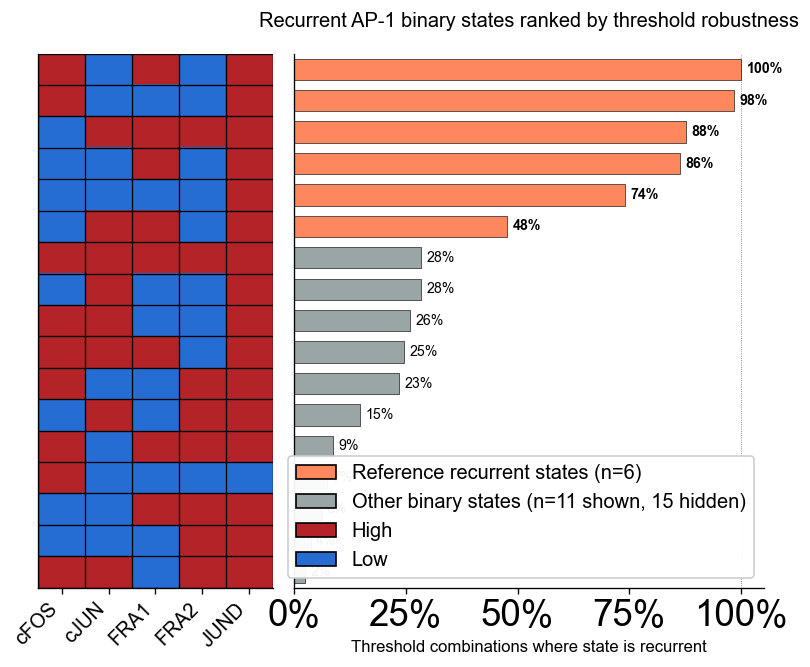

In [23]:
from matplotlib.colors import ListedColormap
from matplotlib.patches import Patch
from sympy import python

# %% Build binary state heatmap matrix ======================================
visible_mask = (
    (stability_df["recurrence_frequency"] > 0)
    | stability_df["in_reference"]
)
visible_df = stability_df[visible_mask].reset_index(drop=True)

n_visible = len(visible_df)
n_ref = len(reference_recurrent)
n_hidden = (~visible_mask).sum()
n_other_visible = n_visible - n_ref

print(
    f"Showing {n_visible} states; hiding {n_hidden} "
    "that never appeared as recurrent."
)

top_states = set(visible_df.head(n_ref)["state"])
reference_states_are_top = top_states == reference_recurrent
print(
    f"Reference states are the top {n_ref} most stable states: "
    f"{reference_states_are_top}"
)

# Convert states to numeric matrix: low = 0, high = 1
state_matrix = np.array([
    [1 if val == "high" else 0 for val in state]
    for state in visible_df["state"]
])


# %% Build figure ===========================================================
fig_height = max(5.5, 0.34 * n_visible)

fig, (ax_heat, ax_bar) = plt.subplots(
    1,
    2,
    figsize=(7.8, fig_height),
    gridspec_kw={"width_ratios": [1.7, 3.4], "wspace": 0.06},
)

y_pos = np.arange(n_visible)

# --------------------------------------------------------------------------
# Left: binary heatmap
# --------------------------------------------------------------------------
low_color = "#266DD3"   # blue
high_color = "#B32328"  # red
state_cmap = ListedColormap([low_color, high_color])

ax_heat.imshow(
    state_matrix,
    aspect="auto",
    cmap=state_cmap,
    vmin=0,
    vmax=1,
    interpolation="nearest",
)

ax_heat.set_xticks(np.arange(len(PROTEINS)))
ax_heat.set_xticklabels(PROTEINS, fontsize=12, rotation=45, ha="right")
ax_heat.set_yticks([])

# Add grid lines between heatmap cells
ax_heat.set_xticks(np.arange(-0.5, len(PROTEINS), 1), minor=True)
ax_heat.set_yticks(np.arange(-0.5, n_visible, 1), minor=True)
ax_heat.grid(which="minor", color="black", linewidth=0.8)
ax_heat.tick_params(which="minor", bottom=False, left=False)

ax_heat.set_ylabel("")

# Align rows with bar plot
ax_heat.set_ylim(n_visible - 0.5, -0.5)

# --------------------------------------------------------------------------
# Right: recurrence-frequency bars
# --------------------------------------------------------------------------
reference_color = "#fe875d"
other_color = "#9aa6a6"

bar_colors = [
    reference_color if is_ref else other_color
    for is_ref in visible_df["in_reference"]
]

recurrence_pct = 100 * visible_df["recurrence_frequency"].values

ax_bar.barh(
    y_pos,
    recurrence_pct,
    color=bar_colors,
    edgecolor="black",
    linewidth=0.35,
    height=0.68,
)

ax_bar.set_ylim(n_visible - 0.5, -0.5)
ax_bar.set_yticks([])

ax_bar.set_xlim(0, 105)
ax_bar.set_xticks(np.arange(0, 101, 25))
ax_bar.set_xticklabels([f"{x}%" for x in np.arange(0, 101, 25)])
ax_bar.set_xlabel(
    "Threshold combinations where state is recurrent",
    fontsize=10,
)

for i, (_, row) in enumerate(visible_df.iterrows()):
    pct = 100 * row["recurrence_frequency"]
    ax_bar.text(
        pct + 1.2,
        i,
        f"{pct:.0f}%",
        va="center",
        fontsize=8.5,
        fontweight="bold" if row["in_reference"] else "normal",
        color="black",
    )

ax_bar.axvline(
    100,
    color="black",
    linewidth=0.5,
    linestyle=":",
    alpha=0.6,
)

ax_bar.set_title(
    "Recurrent AP-1 binary states ranked by threshold robustness",
    fontsize=12,
    pad=16,
)

# --------------------------------------------------------------------------
# Legends
# --------------------------------------------------------------------------
legend_elements = [
    Patch(
        facecolor=reference_color,
        edgecolor="black",
        label=f"Reference recurrent states (n={n_ref})",
    ),
    Patch(
        facecolor=other_color,
        edgecolor="black",
        label=(
            f"Other binary states "
            f"(n={n_other_visible} shown, {n_hidden} hidden)"
        ),
    ),
    Patch(facecolor=high_color, edgecolor="black", label="High"),
    Patch(facecolor=low_color, edgecolor="black", label="Low"),
]

ax_bar.legend(
    handles=legend_elements,
    loc="lower right",
    fontsize=12,
    framealpha=0.95,
)

plt.tight_layout()

plt.savefig(
    f"state_stability_{SWEEP_THRESHOLD_SOURCE}_w{WINDOW_HALF_WIDTH}_ranked_heatmap.pdf",
    dpi=200,
    bbox_inches="tight",
)

plt.show()
